In [1]:
import numpy as np
import py4DSTEM as p4
import matplotlib.pyplot as plt
from IPython.display import display
%matplotlib inline

cupyx.jit.rawkernel is experimental. The interface can change in the future.


In [2]:
import os
import sys
# List h5 files in path directory containing "master" in filename
# path = "/Volumes/Extreme SSD/Data/250801/"
path = "D:\\_Data\\250801\\"
h5_files = [f for f in os.listdir(path) if f.endswith('.h5') and 'master' in f]
print("\nH5 files containing 'master':")
for f in h5_files:
    print(f)


H5 files containing 'master':
._250801_Au_2mrad_115mm_00_master_masked.h5
._250801_Au_2mrad_115mm_00_master_probe.h5
._250801_Au_2mrad_145mm_00_master_masked.h5
._250801_Au_2mrad_145mm_00_master_probe.h5
._250801_Au_2mrad_185mm_01_master_masked.h5
._250801_Au_2mrad_185mm_01_master_probe.h5
._250801_JJ_2mrad_145mm_00_master_masked.h5
07292025_roi12_Au__622urad_35us_CL_91_00_master.h5
07292025_roi12_Au__622urad_35us_CL_91_01_master.h5
250801_Au_2mrad_115mm_00_master.h5
250801_Au_2mrad_115mm_00_master_masked.h5
250801_Au_2mrad_115mm_00_master_probe.h5
250801_Au_2mrad_145mm_00_master.h5
250801_Au_2mrad_145mm_00_master_masked.h5
250801_Au_2mrad_145mm_00_master_probe.h5
250801_Au_2mrad_185mm_00_master.h5
250801_Au_2mrad_185mm_01_master.h5
250801_Au_2mrad_185mm_01_master_masked.h5
250801_Au_2mrad_185mm_01_master_probe.h5
250801_Au_2mrad_58mm_00_master.h5
250801_Au_2mrad_73mm_00_master.h5
250801_Au_2mrad_91mm_00_master.h5
250801_Au_2mrad_91mm_01_master.h5
250801_Au_2mrad_91mm_02_master.h5
250

In [3]:
# set the path to the local copy of the dataset file
name = "250801_JJ_2mrad_145mm_00_master_masked"
filepath_data = path + name + ".h5"

# load the data
datacube = p4.read(filepath_data)



In [4]:
cal_name = "250801_Au_2mrad_145mm_00_master_masked.h5"
cal_probe_name = "250801_Au_2mrad_145mm_00_master_probe.h5"

cal_datacube = p4.read(
    filepath = f'{path}{cal_name}',
)

cal_probe = p4.read(
    filepath = f'{path}{cal_probe_name}',
)

Reading PointListArray: 100%|██████████| 16384/16384 [00:02<00:00, 8188.09PointList/s]


In [5]:
datacube.calibration

Calibration( A Metadata instance called 'calibration', containing the following fields:

             Q_pixel_size:     0.02
             R_pixel_size:     3.061
             Q_pixel_units:    A^-1
             R_pixel_units:    nm
             QR_flip:          False
             _root_treepath:   
)

In [6]:

# datacube.calibration.set_R_pixel_size(3.061)
# datacube.calibration.set_R_pixel_units('nm')


# p4.save(
#     data = datacube,
#     filepath = filepath_data,
#     mode = 'overwrite'
# )

In [7]:
dp_max = datacube.get_dp_max()
dp_mean = datacube.get_dp_mean()

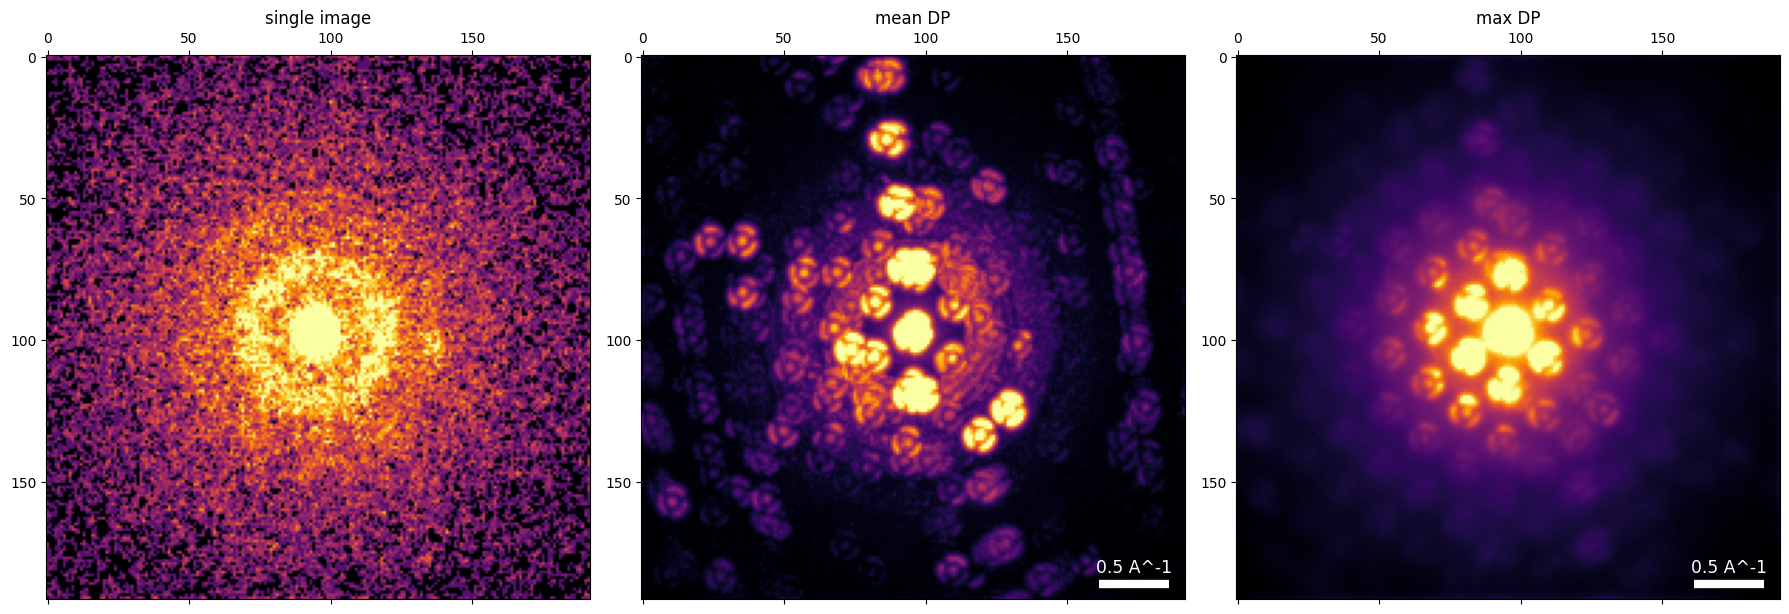

In [8]:
p4.show(
    [datacube.data[40,20],dp_max,dp_mean],
    cmap = 'inferno',
    title = ['single image','mean DP','max DP'],
    power = 0.5,
)
plt.show()

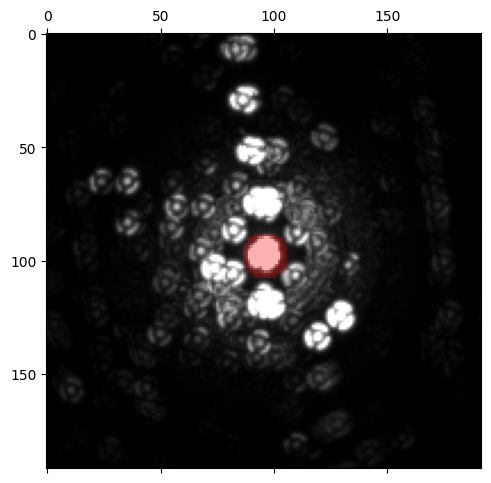

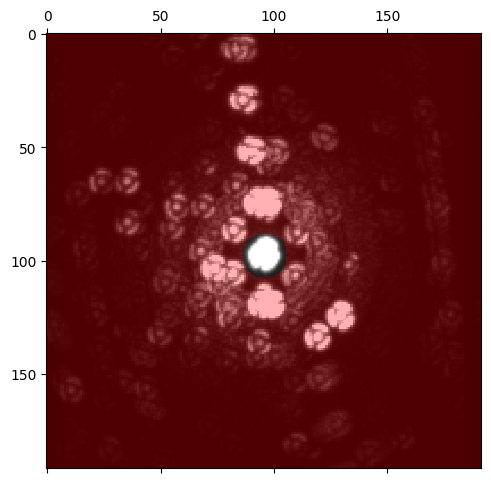

In [9]:
# Virtual imaging - position the detectors

# We'll generate a bright-field (BF) and an annular dark-field (ADF) virtual image
# for both the calibration and measurement datasets

# Set the center
center = (98,96)

# set the geometries
radius_bf = 10
geometry_bf = (center,radius_bf)
geometry_adf = (center,(radius_bf,10e3))

# display the detector positions
datacube.position_detector(
    data = dp_max,
    mode = 'circle',
    geometry = geometry_bf,
)
datacube.position_detector(
    data = dp_max,
    mode = 'annulus',
    geometry = geometry_adf,
)

In [10]:
# Virtual imaging - compute the images

# compute
im_bf = datacube.get_virtual_image(
    mode = 'circle',
    geometry = geometry_bf,
    name = 'bright_field_cal',
)
im_adf = datacube.get_virtual_image(
    mode = 'annulus',
    geometry = geometry_adf,
    name = 'dark_field_cal',
)

# show
p4.show(
    [im_bf,im_adf],
    figsize=(16,2),
    bordercolor = 'w',
    cmap='gray',
    title=['Bright Field (BF)','Annular Dark Field (ADF)'],
    axsize = (2.5,4),
)

100%|██████████| 262144/262144 [00:17<00:00, 14916.78it/s]


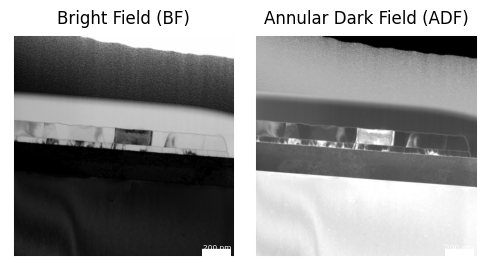

In [11]:
plt.show()

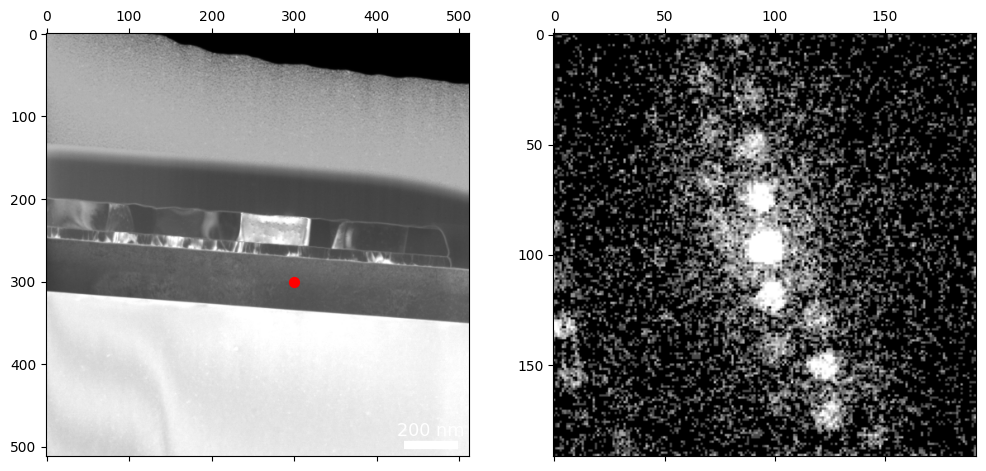

In [12]:
rx,ry = 300,300

p4.visualize.show_selected_dp(
    datacube,
    im_adf,
    rx,
    ry
)

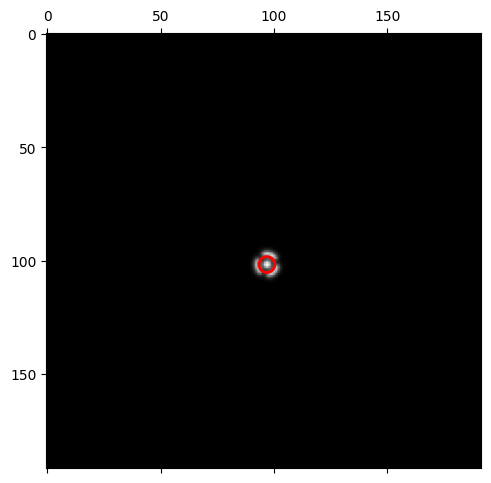

In [13]:
probe_semiangle, probe_qx0, probe_qy0 = p4.process.calibration.get_probe_size(cal_probe.probe)

p4.show(
    cal_probe.probe,
    circle = {
        'center' : (probe_qx0,probe_qy0),
        'R' : probe_semiangle,
    },
    vmax = 1,
)

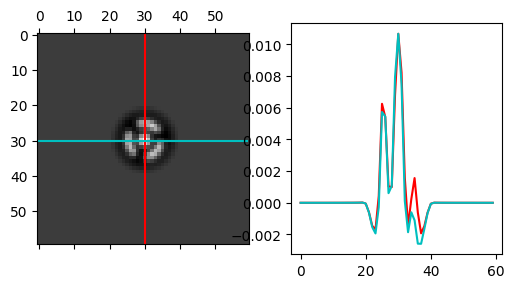

In [14]:
cal_probe.get_kernel(
    mode = 'sigmoid',
    origin = (probe_qx0,probe_qy0),
    radii = (probe_semiangle * 1,
             probe_semiangle * 3,
    )
)

p4.visualize.show_kernel(
    cal_probe.kernel,
    R = 30,
    L = 30,
    W = 1,
    figsize = (6,3),
)

In [15]:
datacube

DataCube( A 4-dimensional array of shape (512, 512, 192, 192) called 'datacube',
          with dimensions:

              Rx = [0.0,3.061,6.122,...] nm
              Ry = [0.0,3.061,6.122,...] nm
              Qx = [0.0,0.02,0.04,...] A^-1
              Qy = [0.0,0.02,0.04,...] A^-1
)

In [16]:
##  Select window to save data
d = datacube
name = 'datacube'

ymin, xmin = 0, 190 #bottom left corner of the window to select
ymax, xmax = 512, 400 #size of the window to select
data_partial = d.data[xmin:xmax,
                      ymin:ymax,
                      :,:]
datacube_partial = p4.DataCube(data = data_partial, calibration=d.calibration)


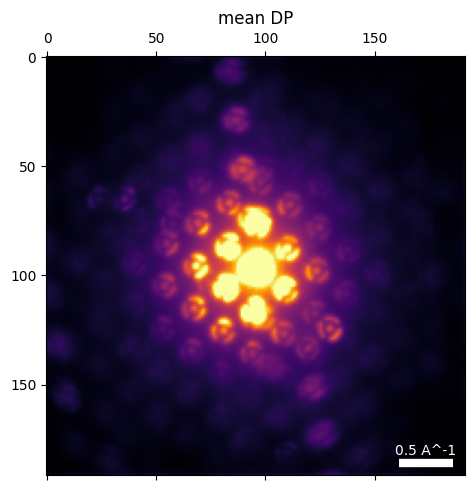

In [17]:
partial_mean = datacube_partial.get_dp_mean()
p4.show(
    partial_mean,
    cmap = 'inferno',
    title = 'mean DP',
    power = 0.5,
)
plt.show()

100%|██████████| 107520/107520 [00:06<00:00, 15474.63it/s]


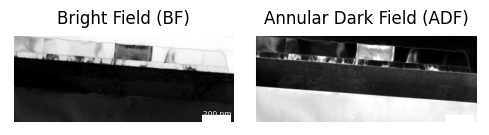

In [18]:
# Virtual imaging - compute the images

# compute
im_bf = datacube_partial.get_virtual_image(
    mode = 'circle',
    geometry = geometry_bf,
    name = 'bright_field_cal',
)
im_adf = datacube_partial.get_virtual_image(
    mode = 'annulus',
    geometry = geometry_adf,
    name = 'dark_field_cal',
)

# show
p4.show(
    [im_bf,im_adf],
    figsize=(16,2),
    bordercolor = 'w',
    cmap='gray',
    title=['Bright Field (BF)','Annular Dark Field (ADF)'],
    axsize = (2.5,4),
)
plt.show()

In [19]:
datacube_partial.calibration


Calibration( A Metadata instance called 'calibration', containing the following fields:

             Q_pixel_size:     0.02
             R_pixel_size:     3.061
             Q_pixel_units:    A^-1
             R_pixel_units:    nm
             QR_flip:          False
             _root_treepath:   
)

In [20]:

p4.save(
    data = datacube_partial,
    filepath = path + f'{name}_partial_loc.h5',
    mode = 'overwrite'
    )


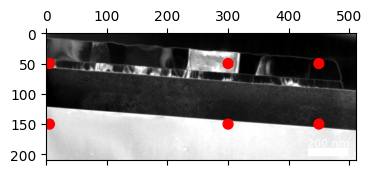

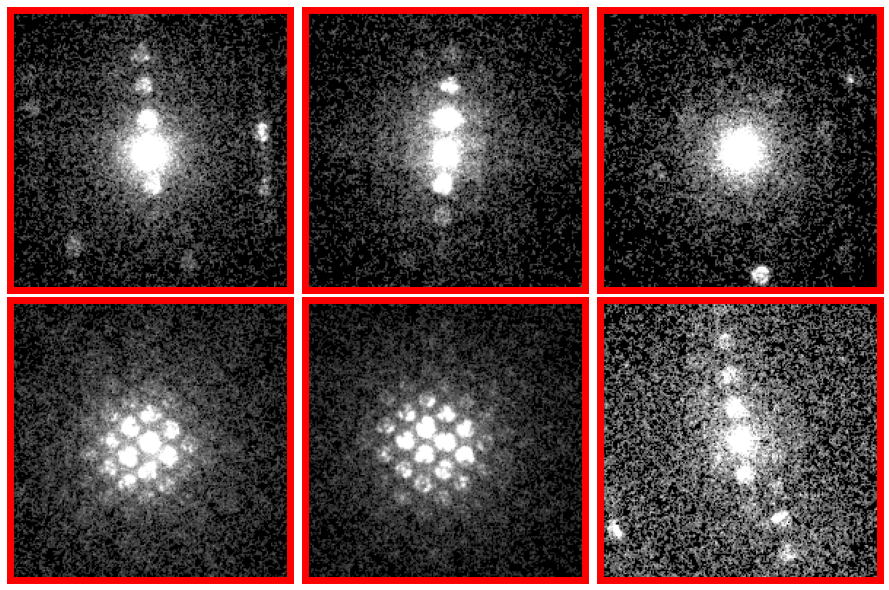

In [21]:
# Choose some diffraction patterns to use for hyperparameter tuning

rxs = 50,50,50,150,150,150
rys = 5,300,450,5,300,450

colors=['r','r','r','r','r','r']


p4.visualize.show_points(
    im_adf,
    x=rxs,
    y=rys,
    pointcolor=colors,
    figsize=(4,4)
)

p4.visualize.show_image_grid(
    get_ar = lambda i:datacube_partial.data[rxs[i],rys[i],:,:],
    H=2,
    W=3,
    axsize=(3,3),
    power = 0.5,
    get_bordercolor = lambda i:colors[i],
)
plt.show()

In [22]:
bg_med = np.median(datacube_partial.data)

def sub_bg(
    im,
    bg_fft=50,
    bg_real = 35,
):
    im_fft = np.fft.fft2(im)
    im_fft = np.maximum(np.abs(im_fft)-bg_fft,0.0) \
        * np.exp(1j * np.angle(im_fft))
    # im_out = np.maximum(np.real(np.fft.ifft2(im_fft)) - bg_real,0.0)
    im_out = np.real(np.fft.ifft2(im_fft)) - bg_real
    return im_out

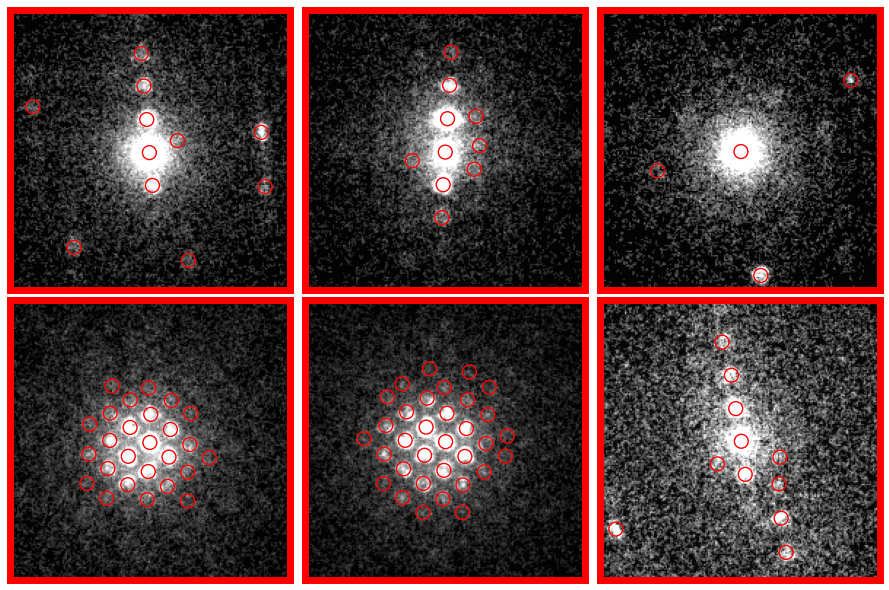

In [23]:
# Tune disk detection parameters

# disk detection parameters
detect_params = {
    'corrPower': 1,
    'sigma': 0,
    'edgeBoundary': 8,
    'minRelativeIntensity': 0.0001,
    'minAbsoluteIntensity': .5,
    'minPeakSpacing': 10,
    'subpixel': 'poly',
    'subpixel' : 'multicorr',
    'upsample_factor': 8,
    'maxNumPeaks': 200,
#     'CUDA': True,
    # 'filter_function': sub_bg,
}
# Note that "poly" subpixel fitting can be used to keep this tutoral fast, but "multicorr"
# is more accurate. For high precision strain mapping, subpixel="multicorr" is recommended.


# find the selected disks
disks_selected = datacube_partial.find_Bragg_disks(
    data = (rxs, rys),
    template = cal_probe.kernel,
    **detect_params,
)

# show
p4.visualize.show_image_grid(
    # get_ar = lambda i:datacube.data[rxs[i],rys[i],:,:],
    get_ar = lambda i:sub_bg(datacube_partial.data[rxs[i],rys[i],:,:]),
    H=2,
    W=3,
    axsize=(3,3),
    power = .5,
    get_bordercolor = lambda i:colors[i],
    get_x = lambda i: disks_selected[i].data['qx'],
    get_y = lambda i: disks_selected[i].data['qy'],
    get_pointcolors = lambda i: colors[i],
    open_circles = True,
    scale = 100,
    # vmin = 0,
    # vmax = 0.,
)
plt.show()

In [24]:
# Find Bragg peaks in all probe positions.

braggpeaks = datacube_partial.find_Bragg_disks(
    template = cal_probe.kernel,
    **detect_params,
)

Finding Bragg Disks: 100%|██████████| 108k/108k [13:54<00:00, 129DP/s]  


In [25]:
file_braggdisks_raw = path+ name + '_braggdisks_raw.h5'
p4.save(
    file_braggdisks_raw,
    braggpeaks,
    mode='o',
)

100%|██████████| 107520/107520 [00:11<00:00, 9299.63it/s]


In [26]:

peaks = p4.read(path + name + '_braggdisks_raw.h5')

Reading PointListArray: 100%|██████████| 107520/107520 [00:12<00:00, 8646.51PointList/s]


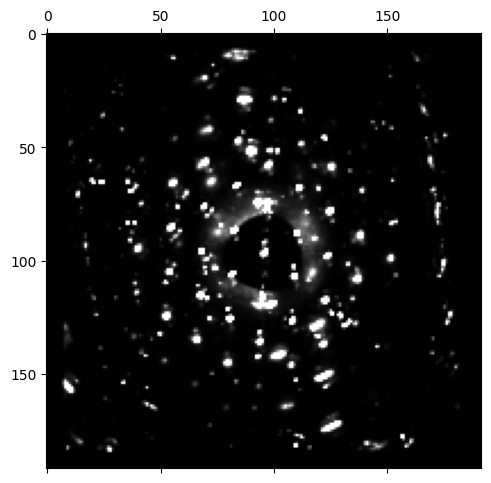

In [27]:
p4.show( braggpeaks.histogram() )

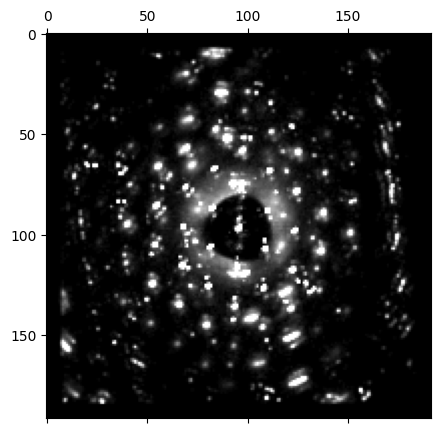

In [28]:
# Compute a Bragg vector map,
# i.e. a 2D histogram of the Bragg peak positions,
# weighted by their correlation intensities

bvm_raw = braggpeaks.histogram(mode = 'raw')

# Plot the BVM
bvm_vis_params = {
    'scaling':'power',
    'power':0.5,
}
p4.show(
    bvm_raw,
    **bvm_vis_params,
    returnfig = True
)
plt.show()

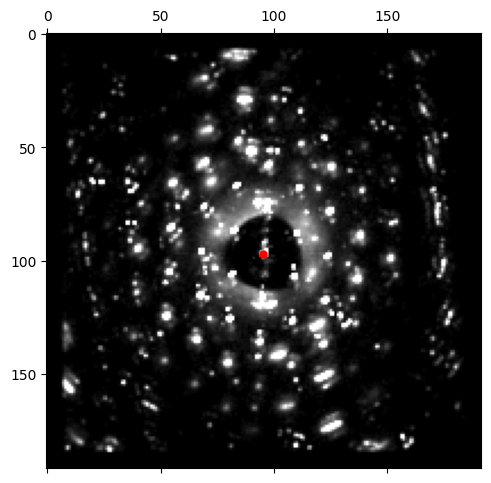

In [29]:
center_guess = 97,95

p4.show(
    bvm_raw,
    points = {'x':center_guess[0],'y':center_guess[1]},
    **bvm_vis_params,
)
plt.show()

In [30]:
# Find the origin at each beam position

# measure the origin
qx0_meas,qy0_meas,mask_meas = braggpeaks.measure_origin( center_guess=center_guess )


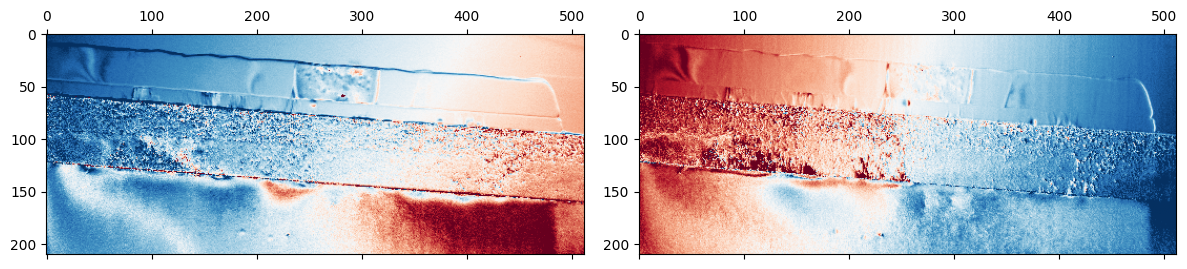

In [31]:
p4.show(
    [qx0_meas,qy0_meas],
    cmap = 'RdBu',
    mask = mask_meas
)
plt.show()

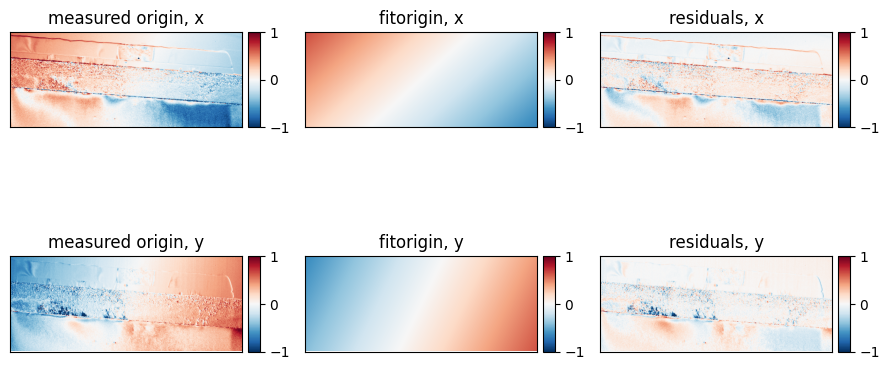

In [32]:

# fit a 2D plane
qx0_fit,qy0_fit,qx0_residuals,qy0_residuals = braggpeaks.fit_origin(
    ticks = False,
    plot_range = 1,
    axsize = (3,4),
)
plt.show()

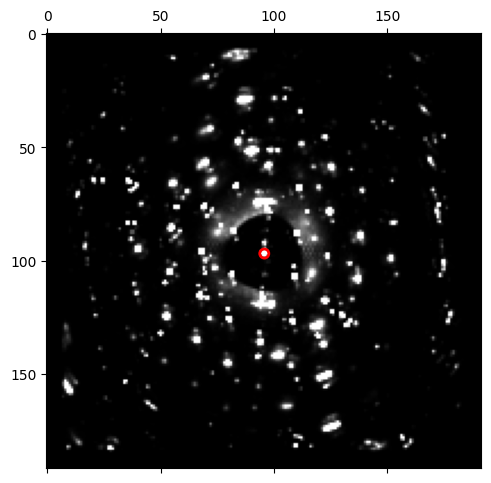

In [33]:
# Get the Bragg vector map after centering using our new origin measurements

# compute
bvm_centered = braggpeaks.histogram()

p4.show(
    bvm_centered,
    circle = {
        'center' : bvm_centered.origin,
        'R' : 2,
    },
    vmin=0,
    vmax=0.98
)
plt.show()

In [34]:
cif_Ta_alpha = "Ta.cif"
cif_Ta_beta = "Ta1.cif"
cif_Al = "Al.cif"
cif_Si = "Si.cif"

In [35]:
crystal_Ta_alpha = p4.process.diffraction.Crystal.from_CIF(cif_Ta_alpha)
crystal_Ta_beta = p4.process.diffraction.Crystal.from_CIF(cif_Ta_beta)
crystal_Al = p4.process.diffraction.Crystal.from_CIF(cif_Al)
crystal_Si = p4.process.diffraction.Crystal.from_CIF(cif_Si)

get_structures is deprecated; use parse_structures in pymatgen.io.cif instead.
The only difference is that primitive defaults to False in the new parse_structures method.So parse_structures(primitive=True) is equivalent to the old behavior of get_structures().


In [36]:
k_max = 1.4

crystal_Ta_alpha.calculate_structure_factors(k_max=k_max)
crystal_Ta_beta.calculate_structure_factors(k_max=k_max)
crystal_Al.calculate_structure_factors(k_max=k_max)
crystal_Si.calculate_structure_factors(k_max=k_max)

In [37]:
# Make orientation plans
# Note that we're doing a coarse search over 4 degree step sizes and only refining to 2 degrees.
# This is done to make the tutorial take much less time.

acom_params = {
    'zone_axis_range': 'auto',

    'angle_step_zone_axis': 2.5,
    'angle_coarse_zone_axis': 5.0,
    'angle_refine_range': 3.0,
    'angle_step_in_plane': 10.0,

    'accel_voltage': 300e3,
    'corr_kernel_size': 0.04,

    'power_intensity': 0.5,
    'power_intensity_experiment': 0.5,

    'sigma_excitation_error': 0.02,
    'precession_angle_degrees': 0.5,
}

crystal_Ta_alpha.orientation_plan(**acom_params)
crystal_Ta_beta.orientation_plan(**acom_params)
crystal_Al.orientation_plan(**acom_params)
crystal_Si.orientation_plan(**acom_params)

Automatically detected point group m-3m,
 using arguments: zone_axis_range = 
[[0 1 1]
 [1 1 1]], 
 fiber_axis=None, fiber_angles=None.


Orientation plan: 100%|██████████| 276/276 [00:00<00:00, 7664.94 zone axes/s]


Automatically detected point group 4/mmm,
 using arguments: zone_axis_range = 
[[1 0 0]
 [1 1 0]], 
 fiber_axis=None, fiber_angles=None.


Orientation plan: 100%|██████████| 703/703 [00:00<00:00, 2479.06 zone axes/s]


Automatically detected point group m-3m,
 using arguments: zone_axis_range = 
[[0 1 1]
 [1 1 1]], 
 fiber_axis=None, fiber_angles=None.


Orientation plan: 100%|██████████| 276/276 [00:00<00:00, 7883.98 zone axes/s]


Automatically detected point group m-3m,
 using arguments: zone_axis_range = 
[[0 1 1]
 [1 1 1]], 
 fiber_axis=None, fiber_angles=None.


Orientation plan: 100%|██████████| 276/276 [00:00<00:00, 5017.09 zone axes/s]


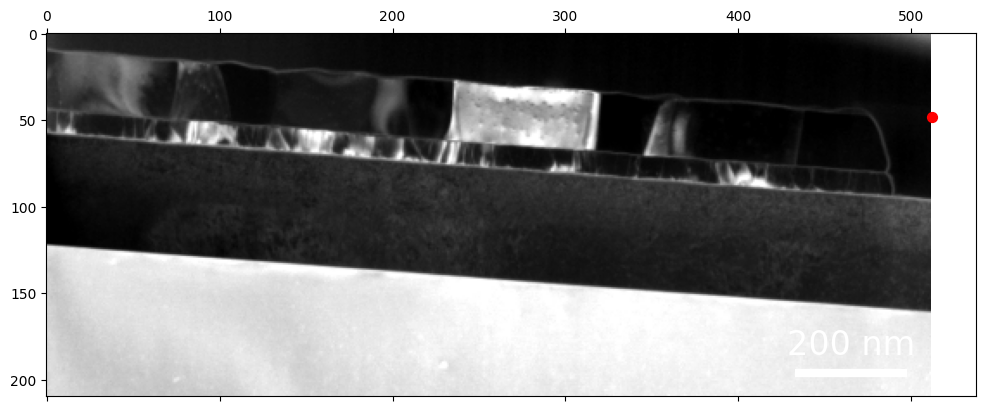

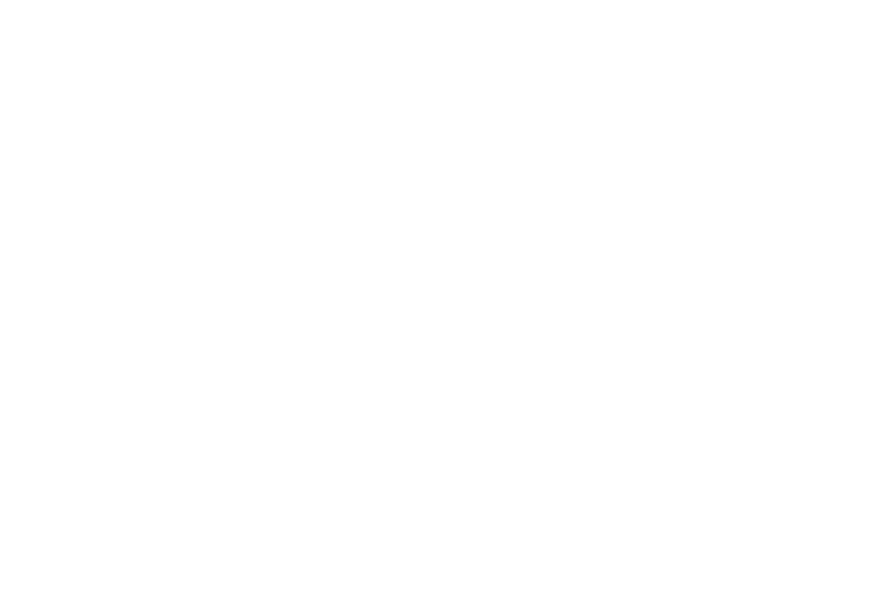

In [38]:
# Choose some diffraction patterns to use for hyperparameter tuning

rxs = 48,
rys = 512,

colors=['r']


p4.visualize.show_points(
    im_adf,
    x=rxs,
    y=rys,
    pointcolor=colors,
    figsize=(12,12)
)

p4.visualize.show_image_grid(
    get_ar = lambda i:datacube_partial.data[rxs[i],rys[i],:,:],
    H=2,
    W=3,
    axsize=(3,3),
    power = 0.5,
    get_bordercolor = lambda i:colors[i],
)
plt.show()

## Cropping Bragg Peaks

In [39]:
# import numpy as np
from matplotlib.path import Path

def mask_from_polygon(shape, corners):
    """
    Returns a boolean mask of shape `shape` that is True outside the polygon defined by `corners`.

    Parameters
    ----------
    shape : tuple
        The (height, width) of the output mask.
    corners : array-like
        List or array of (x, y) tuples specifying the polygon vertices in order.

    Returns
    -------
    mask : np.ndarray
        Boolean array of shape `shape`, True outside the polygon.
    """
    yy, xx = np.meshgrid(np.arange(shape[0]), np.arange(shape[1]), indexing='ij')
    points = np.stack((xx.ravel(), yy.ravel()), axis=-1)
    path = Path(corners)
    mask = path.contains_points(points)
    return (~mask).reshape(shape)


### Al Mask

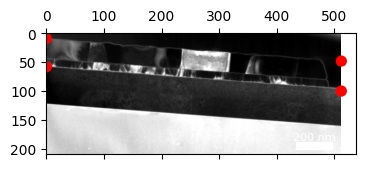

In [40]:
# Choose some diffraction patterns to use for hyperparameter tuning

rxs = 9,48,100,58
rys = 0,512,512,0

colors=['r','r','r','r']


p4.visualize.show_points(
    im_adf,
    x=rxs,
    y=rys,
    pointcolor=colors,
    figsize=(4,4)
)
plt.show()

In [41]:
corners = []
for i in range(len(rxs)):
    corners.append((rys[i],rxs[i]))

al_mask = mask_from_polygon(datacube_partial.data.shape[:2], corners)

# p4.visualize.show_image_grid(
#     get_ar = lambda i:datacube.data[rxs[i],rys[i],:,:],
#     H=2,
#     W=3,
#     axsize=(3,3),
#     power = 0.5,
#     get_bordercolor = lambda i:colors[i],
# )
# plt.show()

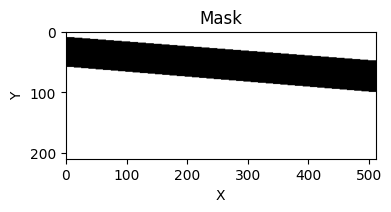

In [42]:
plt.figure(figsize=(4,4))
plt.imshow(al_mask, cmap='gray')
plt.title('Mask')
plt.xlabel('X')
plt.ylabel('Y')
plt.show()


In [43]:
import math

def _points_to_coeffs(p1: tuple[float, float], p2: tuple[float, float]) -> tuple[float, float, float]:
    """Converts two points into the general line equation Ax + By + C = 0."""
    x1, y1 = p1
    x2, y2 = p2
    
    if math.isclose(x1, x2) and math.isclose(y1, y2):
        raise ValueError("Cannot define a line with two identical points.")
        
    A = y2 - y1
    B = x1 - x2
    C = x2 * y1 - x1 * y2
    return A, B, C

def calculate_line_distance_from_points(
    line1_p1: tuple[float, float], line1_p2: tuple[float, float],
    line2_p1: tuple[float, float], line2_p2: tuple[float, float],
    x_val: float | None = None,
    y_val: float | None = None
) -> float:
    """
    Calculates distance between two lines defined by points.

    Args:
        line1_p1: First point on line 1.
        line1_p2: Second point on line 1.
        line2_p1: First point on line 2.
        line2_p2: Second point on line 2.
        x_val: The x-coordinate for calculating vertical distance.
        y_val: The y-coordinate for calculating horizontal distance.

    Returns:
        The calculated distance.
    """
    # Convert the points for each line into A, B, C coefficients
    line1_coeffs = _points_to_coeffs(line1_p1, line1_p2)
    line2_coeffs = _points_to_coeffs(line2_p1, line2_p2)
    
    # Use the original function to calculate the distance
    return _calculate_distance_from_coeffs(line1_coeffs, line2_coeffs, x_val, y_val)


# This is the core calculation function from the previous answer
def _calculate_distance_from_coeffs(
    line1: tuple[float, float, float],
    line2: tuple[float, float, float],
    x_val: float | None = None,
    y_val: float | None = None
) -> float:
    """Calculates distance between two lines from their Ax+By+C=0 coefficients."""
    A1, B1, C1 = line1
    A2, B2, C2 = line2

    # Check for parallelism using determinant A1*B2 - A2*B1 = 0
    if math.isclose(A1 * B2, A2 * B1):
        # --- Lines are PARALLEL ---
        if math.isclose(A2, 0) and math.isclose(B2, 0):
            raise ValueError("Line 2 is not a valid line.")
        
        # Find a point (x0, y0) on line 1
        if not math.isclose(B1, 0):
            x0, y0 = 0, -C1 / B1
        else:
            x0, y0 = -C1 / A1, 0
        
        numerator = abs(A2 * x0 + B2 * y0 + C2)
        denominator = math.sqrt(A2**2 + B2**2)
        
        return 0.0 if math.isclose(denominator, 0) else numerator / denominator

    else:
        # --- Lines are NOT PARALLEL (they intersect) ---
        if x_val is not None and y_val is not None:
            raise ValueError("Provide either x_val or y_val, not both.")

        if x_val is not None:
            # Calculate vertical distance at a given x
            if math.isclose(B1, 0) or math.isclose(B2, 0):
                raise ValueError("Cannot calculate vertical distance; one or both lines are vertical.")
            y1 = (-A1 * x_val - C1) / B1
            y2 = (-A2 * x_val - C2) / B2
            return abs(y1 - y2)

        if y_val is not None:
            # Calculate horizontal distance at a given y
            if math.isclose(A1, 0) or math.isclose(A2, 0):
                raise ValueError("Cannot calculate horizontal distance; one or both lines are horizontal.")
            x1 = (-B1 * y_val - C1) / A1
            x2 = (-B2 * y_val - C2) / A2
            return abs(x1 - x2)
        
        # The shortest distance between non-parallel lines is 0 at their intersection.
        return 0.0
# Define the points for each line
p1_1, p1_2 = corners[:2]
p2_1, p2_2 = corners[2:]

# Calculate the vertical distance at x=10
distance = calculate_line_distance_from_points(
    p1_1, p1_2,
    p2_1, p2_2,
    x_val=10
)

print(f"The vertical distance between the lines at x=10 is: {distance}")
# The vertical distance between the lines at x=10 is: 3.0

The vertical distance between the lines at x=10 is: 49.05859375


In [44]:
Al_peaks = braggpeaks.copy().mask_in_R(al_mask)

### Ta Mask

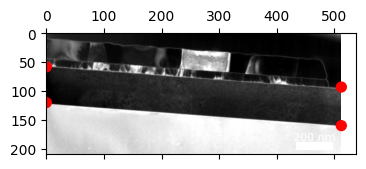

In [82]:
# Choose some diffraction patterns to use for hyperparameter tuning

rxs = 93,58,120,160
rys = 512,0,0,512

colors=['r','r','r','r']


p4.visualize.show_points(
    im_adf,
    x=rxs,
    y=rys,
    pointcolor=colors,
    figsize=(4,4)
)
plt.show()

In [46]:
corners

[(0, 9), (512, 48), (512, 100), (0, 58)]

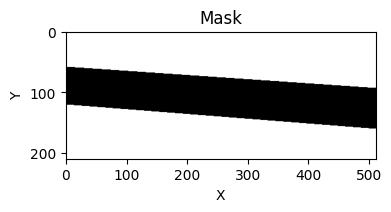

In [83]:
corners = []
for i in range(len(rxs)):
    corners.append((rys[i],rxs[i]))

ta_mask = mask_from_polygon(datacube_partial.data.shape[:2], corners)

# p4.visualize.show_image_grid(
#     get_ar = lambda i:datacube.data[rxs[i],rys[i],:,:],
#     H=2,
#     W=3,
#     axsize=(3,3),
#     power = 0.5,
#     get_bordercolor = lambda i:colors[i],
# )
# plt.show()

plt.figure(figsize=(4,4))
plt.imshow(ta_mask, cmap='gray')
plt.title('Mask')
plt.xlabel('X')
plt.ylabel('Y')
plt.show()


In [84]:
Ta_peaks = braggpeaks.copy().mask_in_R(ta_mask)


### Si Mask

In [49]:
corners = []
for i in range(2,len(rxs)):
    corners.append((rys[i],rxs[i]))
corners.append((512,512))
corners.append((0,512))


si_mask = mask_from_polygon(datacube_partial.data.shape[:2], corners)

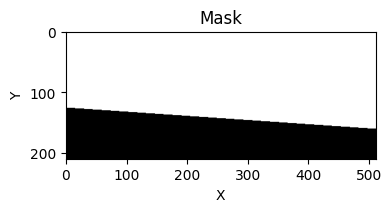

In [50]:
plt.figure(figsize=(4,4))
plt.imshow(si_mask, cmap='gray')
plt.title('Mask')
plt.xlabel('X')
plt.ylabel('Y')
plt.show()

In [51]:
Si_peaks = braggpeaks.copy().mask_in_R(si_mask)

## Fitting Bragg Peaks

Best fit lattice directions: z axis = ([0.141 0.673 0.726]), x axis = ([0.134 0.688 0.714]), with corr value = 1.695
Best fit lattice directions: z axis = ([0.122 0.158 0.98 ]), x axis = ([0.051 0.612 0.789]), with corr value = 1.367
Best fit lattice directions: z axis = ([0.739 0.022 0.673]), x axis = ([0.85  0.149 0.505]), with corr value = 1.317
Best fit lattice directions: z axis = ([0.924 0.383 0.   ]), x axis = ([0.335 0.139 0.932]), with corr value = 0.755


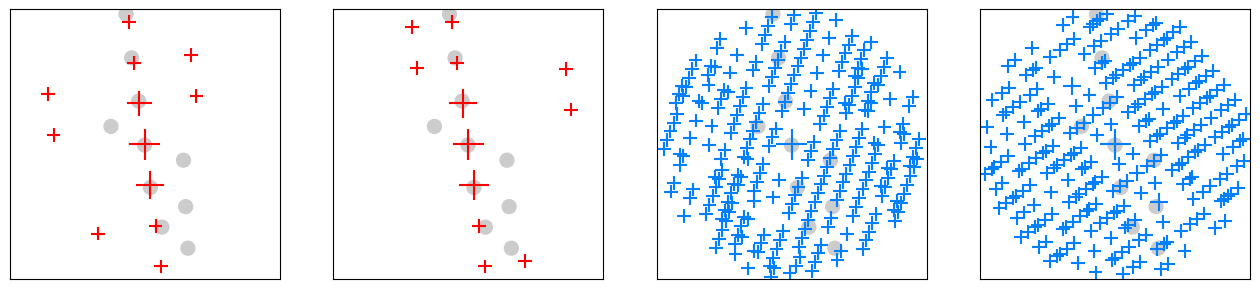

In [85]:
# Test orientation_matching on some probe positions


xind, yind = 100,150

min_angle_between_matches_deg = 30
precession_angle_degrees = 0.5
sigma_compare = 0.02
num_matches_return = 2


# Fit all crystals
orientation_Ta_alpha  = crystal_Ta_alpha.match_single_pattern(
    braggpeaks.cal[xind,yind],
    num_matches_return = num_matches_return,
    verbose = True,
    min_angle_between_matches_deg=min_angle_between_matches_deg,
)
orientation_Ta_beta  = crystal_Ta_beta.match_single_pattern(
    braggpeaks.cal[xind,yind],
    num_matches_return = num_matches_return,
    verbose = True,
    min_angle_between_matches_deg=min_angle_between_matches_deg,
)


# Generate test diffraction patterns for matches 0 and 1
bragg_peaks_fit_Ta_alpha_0 = crystal_Ta_alpha.generate_diffraction_pattern(
    orientation_Ta_alpha,
    ind_orientation=0,
    sigma_excitation_error=sigma_compare,
    precession_angle_degrees = precession_angle_degrees,
)
bragg_peaks_fit_Ta_alpha_1 = crystal_Ta_alpha.generate_diffraction_pattern(
    orientation_Ta_alpha,
    ind_orientation=1,
    sigma_excitation_error=sigma_compare,
    precession_angle_degrees = precession_angle_degrees,
)

bragg_peaks_fit_Ta_beta_0 = crystal_Ta_beta.generate_diffraction_pattern(
    orientation_Ta_beta,
    ind_orientation=0,
    sigma_excitation_error=sigma_compare,
    precession_angle_degrees = precession_angle_degrees,
)
bragg_peaks_fit_Ta_beta_1 = crystal_Ta_beta.generate_diffraction_pattern(
    orientation_Ta_beta,
    ind_orientation=1,
    sigma_excitation_error=sigma_compare,
    precession_angle_degrees = precession_angle_degrees,
)


# plotting frame
figsize = (4,4)
fig,ax = plt.subplots(1,4,figsize=(4*figsize[0],1*figsize[1]))

plot_params = {
    'bragg_peaks_compare':     braggpeaks.cal[xind,yind],
    # 'plot_range_kx_ky':  np.array([k_max,k_max]),
    'plot_range_kx_ky':  np.array([1.4,1.4]),
    'min_marker_size': 100,
    'max_marker_size': 500,
    'add_labels': False,

    'scale_markers': 4000,
    'scale_markers_compare': 0.02,
    'marker': '+',
    'facecolor_compare': (0.8,0.8,0.8),

    # 'color':(1,0,0),
    'edgecolor': None,
    # 'facecolor': 'none',
    'linewidth':1.5,
    'show_axes':False
}


# plot comparisons
# Ti alpha
p4.process.diffraction.plot_diffraction_pattern(
    bragg_peaks = bragg_peaks_fit_Ta_alpha_0,
    input_fig_handle=(fig,[ax[0]]),
    color = (1.0,0.0,0.0),
    **plot_params,
)
p4.process.diffraction.plot_diffraction_pattern(
    bragg_peaks = bragg_peaks_fit_Ta_alpha_1,
    input_fig_handle=(fig,[ax[1]]),
    color = (1.0,0.0,0.0),
    **plot_params,
)
# Ti beta
p4.process.diffraction.plot_diffraction_pattern(
    bragg_peaks = bragg_peaks_fit_Ta_beta_0,
    input_fig_handle=(fig,[ax[2]]),
    color = (0.0,0.5,1.0),
    **plot_params,
)
p4.process.diffraction.plot_diffraction_pattern(
    bragg_peaks = bragg_peaks_fit_Ta_beta_1,
    input_fig_handle=(fig,[ax[3]]),
    color = (0.0,0.5,1.0),
    **plot_params,
)
plt.show()

In [86]:
# Fit orientation to all probe positions
num_matches_return = 1
min_angle_between_matches_deg = 30

orientation_map_Ta_alpha = crystal_Ta_alpha.match_orientations(
    Ta_peaks,
    num_matches_return = num_matches_return,
    min_angle_between_matches_deg = min_angle_between_matches_deg,
)



bragg peaks not rotationally calibrated
Matching Orientations: 100%|██████████| 107520/107520 [01:13<00:00, 1467.39 PointList/s] 


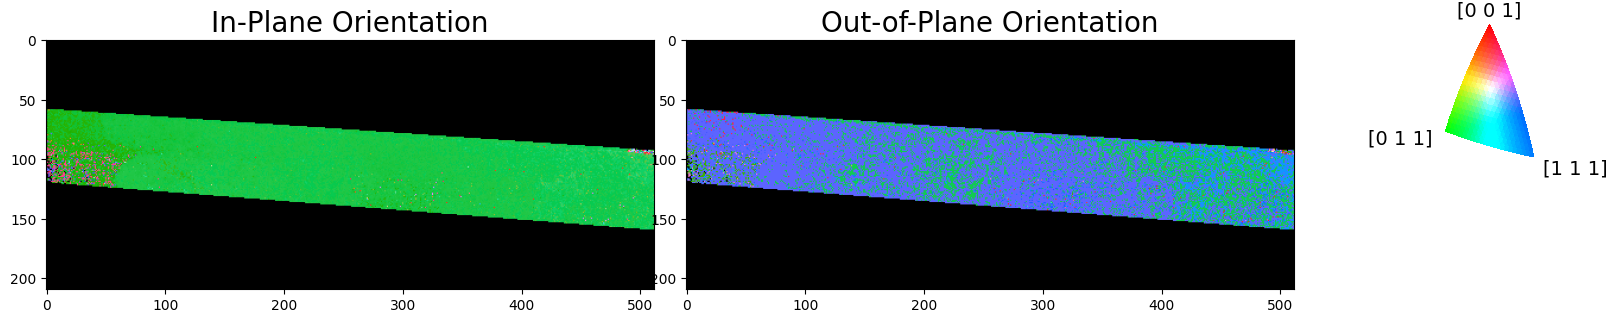

In [140]:
c_r = (0,0.01)

im_alpha = crystal_Ta_alpha.plot_orientation_maps(
    orientation_map = crystal_Ta_alpha.orientation_map,
    corr_range = c_r,
    figsize = (16,8),
    show_legend = True,
    # camera_dist = 10,
    returnfig = True,
)
plt.show()

In [292]:
arr, fig, axes = im_alpha
axes[0].set_title('Ta alpha In-Plane Orientation Map')
axes[1].set_title('Ta alpha Out-of-Plane Orientation Map')

# fig.savefig('orientation_map_Ta_alpha.png',dpi=300)


Text(0.5, 1.0, 'Ta alpha Out-of-Plane Orientation Map')

#### Rotate and Denoise Image

In [293]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.transform import AffineTransform, warp


In [294]:
blurred = arr[:,:,:,1]

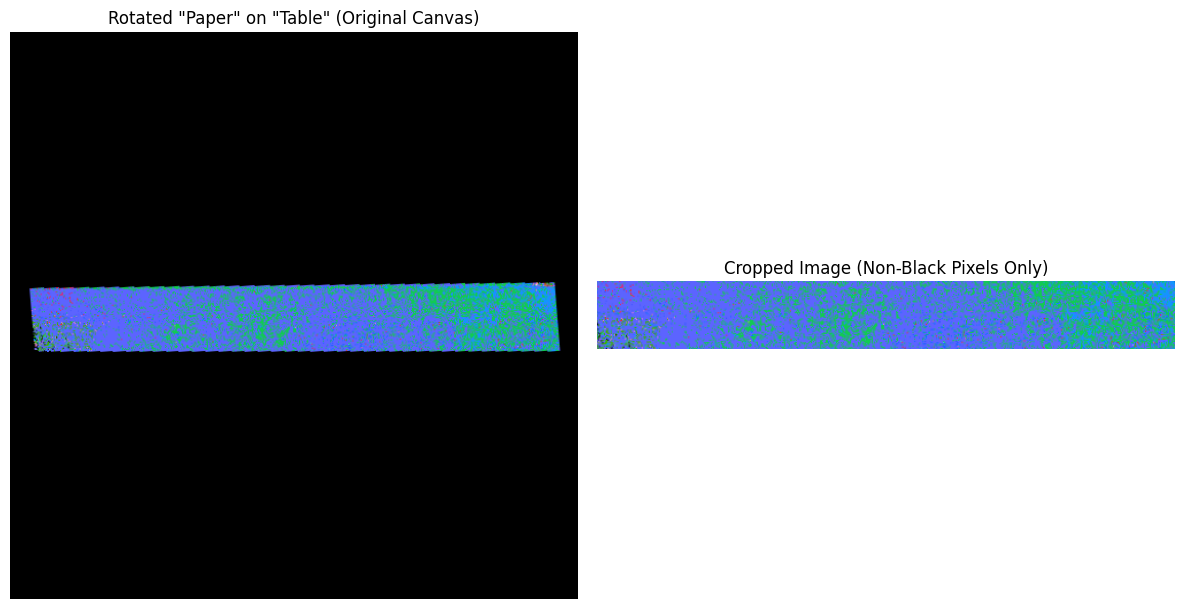

Original 'table' shape: (554, 554)
Cropped image shape:    (59, 503)


In [295]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.transform import AffineTransform, warp


padding = 0.00
row_min_offset = 8
row_max_offset = -3
col_min_offset = 10
col_max_offset = -5

# --- Setup from the previous step ---
h, w = blurred.shape[0], blurred.shape[1]
paper = blurred*255
rotation_angle_degrees = -4.5
diagonal = int(np.ceil(np.sqrt(h**2 + w**2)))
table_size = (diagonal, diagonal)
paper_center_x, paper_center_y = w / 2, h / 2
table_center_x, table_center_y = diagonal / 2, diagonal / 2
transform = (
    AffineTransform(translation=(-paper_center_x, -paper_center_y)) +
    AffineTransform(rotation=np.deg2rad(rotation_angle_degrees)) +
    AffineTransform(translation=(table_center_x, table_center_y))
)
rotated_paper_on_table = warp(
    paper,
    transform.inverse,
    output_shape=table_size,
    preserve_range=True
).astype(np.uint8)


# --- 1. Create a boolean mask of non-black pixels ---
is_not_black = rotated_paper_on_table.sum(axis=2) > 0


# --- 2. Find the bounding box from the mask ---
# `np.where(is_not_black)` returns the (row_indices, col_indices) of all True values.
rows, cols = np.where(is_not_black)

# If there are no non-black pixels (e.g., if the image is entirely black),
# handle this to prevent errors.
if rows.size == 0 or cols.size == 0:
    print("No non-black pixels found, returning an empty or original image.")
    cropped_image_final = rotated_paper_on_table # Or np.array([])
else:
    min_row, max_row = int(np.min(rows)*(1+padding))+row_min_offset, int(np.max(rows)*(1-padding))+row_max_offset
    min_col, max_col = int(np.min(cols)*(1+padding))+col_min_offset, int(np.max(cols)*(1-padding))+col_max_offset

    # Add 1 to max_row and max_col to include the last pixel in the slice
    cropped_image_final = rotated_paper_on_table[min_row:max_row+1, min_col:max_col+1]


# --- 3. Display the results ---
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(rotated_paper_on_table)
axes[0].set_title('Rotated "Paper" on "Table" (Original Canvas)')
axes[0].axis('off')

axes[1].imshow(cropped_image_final)
axes[1].set_title('Cropped Image (Non-Black Pixels Only)')
axes[1].axis('off')

plt.tight_layout()
plt.show()

print(f"Original 'table' shape: {rotated_paper_on_table.shape[:2]}")
if 'cropped_image_final' in locals():
    print(f"Cropped image shape:    {cropped_image_final.shape[:2]}")

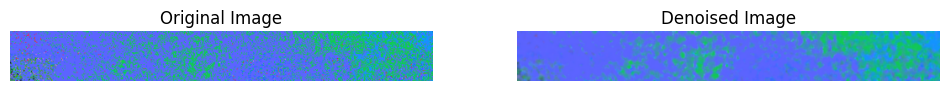

In [301]:
import numpy as np
from scipy.ndimage import gaussian_filter
import matplotlib.pyplot as plt
from scipy.ndimage import median_filter
from scipy.ndimage import uniform_filter

# 1. Create a sample RGB image array (height, width, 3)
# Here, we'll create a 300x400 image with random colors
original_image = cropped_image_final

# 2. Define the strength of the blur (standard deviation)
# A larger sigma means more blur.
sigma_value = 0.2

# 3. Apply the Gaussian filter
# We provide a sigma for each axis.
# (sigma_for_rows, sigma_for_cols, sigma_for_channels)
# Setting the channel sigma to 0 prevents blurring across colors.
blurred_image = gaussian_filter(original_image, sigma=(sigma_value, sigma_value, 0))
denoised = median_filter(blurred_image, size=(4, 4, 1))
blurred = uniform_filter(denoised, size=(2, 2, 1))

# 4. Display the results
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(original_image)
axes[0].set_title('Original Image')
axes[0].axis('off')

axes[1].imshow(blurred)
axes[1].set_title(f'Denoised Image')
axes[1].axis('off')

plt.show()

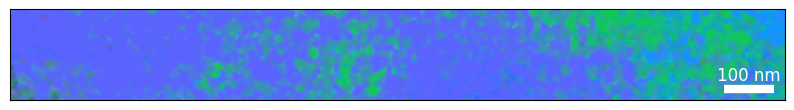

In [302]:
fig = p4.show(
    blurred,
    scalebar = {'Nx': 100, 'Ny': 200, 'pixel_size': 10},
    space = 'R',
    calibration = datacube.calibration,
    returnfig = True,
    ticks = False,
    figsize = (10,6)
    
    )
plt.show()

In [303]:
fig[0].savefig('orientation_map_Ta_alpha.png',dpi=300)

### Map Si

In [58]:
orientation_map_Si = crystal_Si.match_orientations(
    Si_peaks,
    num_matches_return = num_matches_return,
    min_angle_between_matches_deg = min_angle_between_matches_deg,
)

orientation_map_Al = crystal_Al.match_orientations(
    Al_peaks,
    num_matches_return = num_matches_return,
    min_angle_between_matches_deg = min_angle_between_matches_deg,
)

bragg peaks not rotationally calibrated
Matching Orientations: 100%|██████████| 107520/107520 [01:23<00:00, 1293.24 PointList/s]
bragg peaks not rotationally calibrated
Matching Orientations: 100%|██████████| 107520/107520 [00:54<00:00, 1960.85 PointList/s] 


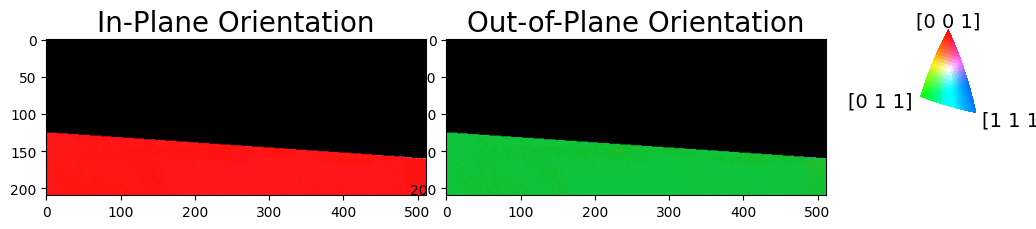

In [59]:
c_r = (0,0.01)

im_Si = crystal_Si.plot_orientation_maps(
    orientation_map = crystal_Si.orientation_map,
    corr_range = c_r,
    figsize = (10,4),
    show_legend = True,
    # camera_dist = 10,
    returnfig = True,
    
)
# plt.savefig('orientation_map_Si.png')

In [60]:
arr, fig, axes = im_Si
axes[0].set_title('Si In-Plane Orientation Map')
axes[1].set_title('Si Out-of-Plane Orientation Map')

# fig.savefig('orientation_map_Si.png',dpi=300)

Text(0.5, 1.0, 'Si Out-of-Plane Orientation Map')

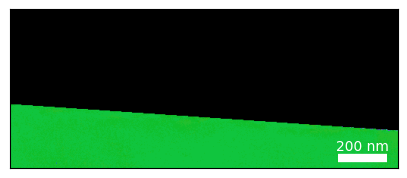

In [61]:
fig = p4.show(
    arr[:,:,:,1],
    scalebar = {},
    space = 'R',
    calibration = datacube.calibration,
    returnfig = True,
    ticks = False
    
    )
plt.show()

In [62]:
fig[0].savefig('orientation_map_Si.png',dpi=300)

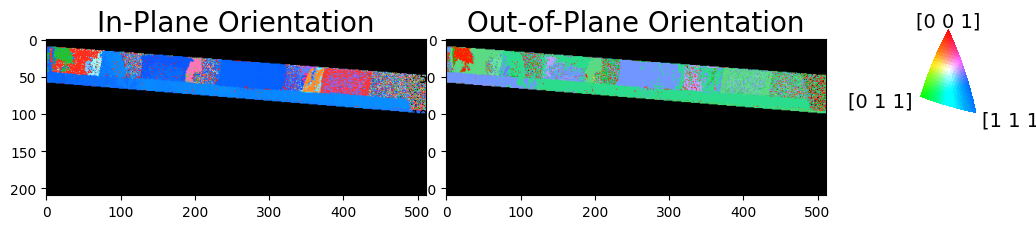

In [63]:
c_r = (0,0.01)

im_Al = crystal_Al.plot_orientation_maps(
    orientation_map = crystal_Al.orientation_map,
    corr_range = c_r,
    figsize = (10,4),
    show_legend = True,
    # camera_dist = 10,
    returnfig = True,
)
plt.show()

In [270]:
arr, fig, axes = im_Al
axes[0].set_title('Al In-Plane Orientation Map')
axes[1].set_title('Al Out-of-Plane Orientation Map')

# fig.savefig('orientation_map_Al.png',dpi=300)


Text(0.5, 1.0, 'Al Out-of-Plane Orientation Map')

In [271]:
blurred = arr[:,:,:,1]

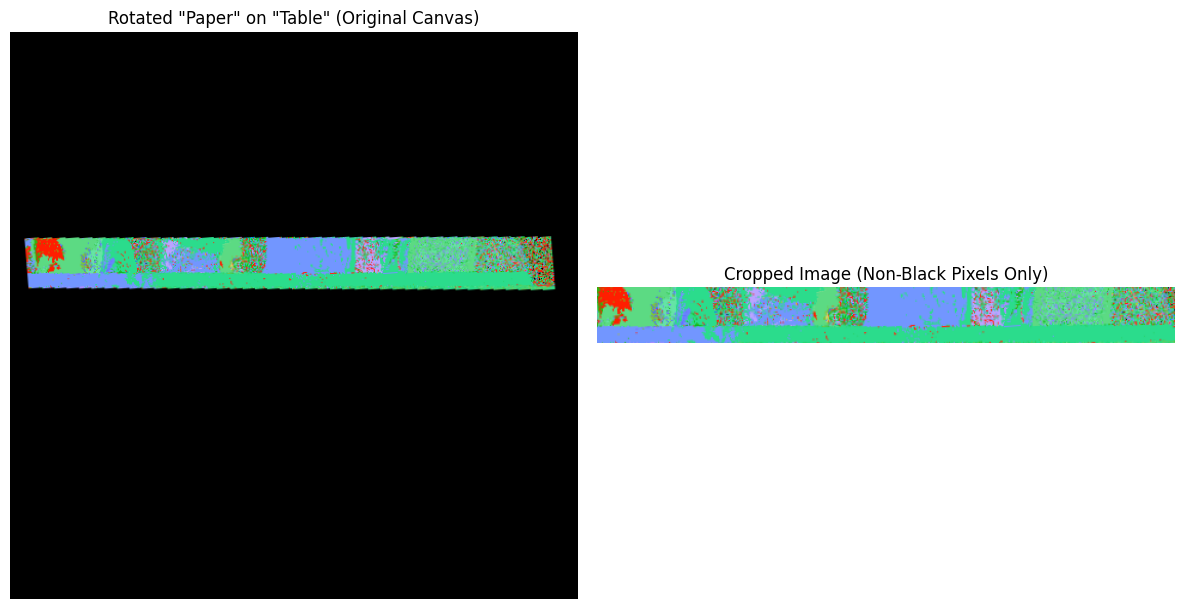

Original 'table' shape: (554, 554)
Cropped image shape:    (47, 483)


In [272]:
padding = 0.00
row_min_offset = 3
row_max_offset = -3
col_min_offset = 10
col_max_offset = -25

# --- Setup from the previous step ---
h, w = blurred.shape[0], blurred.shape[1]
paper = blurred*255
rotation_angle_degrees = -4.5
diagonal = int(np.ceil(np.sqrt(h**2 + w**2)))
table_size = (diagonal, diagonal)
paper_center_x, paper_center_y = w / 2, h / 2
table_center_x, table_center_y = diagonal / 2, diagonal / 2
transform = (
    AffineTransform(translation=(-paper_center_x, -paper_center_y)) +
    AffineTransform(rotation=np.deg2rad(rotation_angle_degrees)) +
    AffineTransform(translation=(table_center_x, table_center_y))
)
rotated_paper_on_table = warp(
    paper,
    transform.inverse,
    output_shape=table_size,
    preserve_range=True
).astype(np.uint8)


# --- 1. Create a boolean mask of non-black pixels ---
is_not_black = rotated_paper_on_table.sum(axis=2) > 0


# --- 2. Find the bounding box from the mask ---
# `np.where(is_not_black)` returns the (row_indices, col_indices) of all True values.
rows, cols = np.where(is_not_black)

# If there are no non-black pixels (e.g., if the image is entirely black),
# handle this to prevent errors.
if rows.size == 0 or cols.size == 0:
    print("No non-black pixels found, returning an empty or original image.")
    cropped_image_final = rotated_paper_on_table # Or np.array([])
else:
    min_row, max_row = int(np.min(rows)*(1+padding))+row_min_offset, int(np.max(rows)*(1-padding))+row_max_offset
    min_col, max_col = int(np.min(cols)*(1+padding))+col_min_offset, int(np.max(cols)*(1-padding))+col_max_offset

    # Add 1 to max_row and max_col to include the last pixel in the slice
    cropped_image_final = rotated_paper_on_table[min_row:max_row+1, min_col:max_col+1]


# --- 3. Display the results ---
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(rotated_paper_on_table)
axes[0].set_title('Rotated "Paper" on "Table" (Original Canvas)')
axes[0].axis('off')

axes[1].imshow(cropped_image_final)
axes[1].set_title('Cropped Image (Non-Black Pixels Only)')
axes[1].axis('off')

plt.tight_layout()
plt.show()

print(f"Original 'table' shape: {rotated_paper_on_table.shape[:2]}")
if 'cropped_image_final' in locals():
    print(f"Cropped image shape:    {cropped_image_final.shape[:2]}")

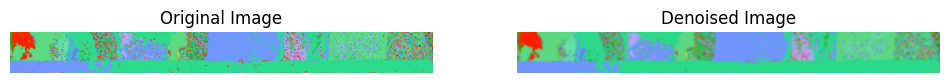

In [289]:
import numpy as np
from scipy.ndimage import gaussian_filter
import matplotlib.pyplot as plt
from scipy.ndimage import median_filter
from scipy.ndimage import uniform_filter

# 1. Create a sample RGB image array (height, width, 3)
# Here, we'll create a 300x400 image with random colors
original_image = cropped_image_final

# 2. Define the strength of the blur (standard deviation)
# A larger sigma means more blur.
sigma_value = 0.3

# 3. Apply the Gaussian filter
# We provide a sigma for each axis.
# (sigma_for_rows, sigma_for_cols, sigma_for_channels)
# Setting the channel sigma to 0 prevents blurring across colors.
blurred_image = gaussian_filter(original_image, sigma=(sigma_value, sigma_value, 0))
denoised = median_filter(blurred_image, size=(3, 3, 1))
blurred = uniform_filter(denoised, size=(2, 2, 1))

# 4. Display the results
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(original_image)
axes[0].set_title('Original Image')
axes[0].axis('off')

axes[1].imshow(blurred)
axes[1].set_title(f'Denoised Image')
axes[1].axis('off')

plt.show()

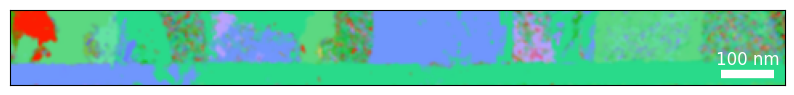

In [290]:
fig = p4.show(
    blurred,
    scalebar = {},
    space = 'R',
    calibration = datacube.calibration,
    returnfig = True,
    ticks = False,
    figsize = (10,6)
    
    )
plt.show()

In [291]:

fig[0].savefig('orientation_map_Al.png',dpi=300)